## Discretization

Discretization is the process of transforming continuous variables into discrete variables by creating a set of contiguous intervals that span the range of the variable's values. Discretization is also called **binning**, where bin is an alternative name for interval.


### Discretization helps handle outliers and may improve the value spread in skewed variables

Discretization helps handle outliers by placing these values into the lower or higher intervals, together with the remaining inlier values of the distribution. Thus, these outlier observations no longer differ from the rest of the values at the tails of the distribution, as they are now all together in the same interval or bucket. In addition, by creating appropriate bins or intervals, discretization can help spread the values of a skewed variable across a set of bins with an equal number of observations.


### Discretization approaches

There are several approaches to transform continuous variables into discrete ones. Discretization methods fall into 2 categories: **supervised and unsupervised**. Unsupervised methods do not use any information other than the variable distribution to create the contiguous bins in which the values will be placed. Supervised methods typically use target information in order to create the bins or intervals.


####  Unsupervised discretization methods

- Equal width discretisation
- Equal frequency discretization
- K-means discretization

#### Supervised discretization methods

- Discretization using decision trees


## Equal width discretization

Equal width discretization divides the scope of possible values into N bins of the same width. The width is determined by the range of values in the variable and the number of bins we wish to use to divide the variable:

width = (max value - min value) / N

where N is the number of bins or intervals.

For example, if the values of the variable vary between 0 and 100, we create 5 bins like this: width = (100-0) / 5 = 20. The bins thus are 0-20, 20-40, 40-60, 80-100. The first and final bins (0-20 and 80-100) can be expanded to accommodate outliers (that is, values under 0 or greater than 100 would be placed in those bins as well).

There is no rule of thumb to define N; that is something to determine experimentally.

## Equal frequency discretization

Equal frequency discretization divides the scope of possible values of the variable into N bins, where each bin carries the same amount of observations. This is particularly useful for skewed variables, as it spreads the observations over the different bins equally. We find the interval boundaries by determining the quantiles.

Equal frequency discretization using quantiles consists of dividing the continuous variable into N quantiles, where N to be defined by the user.

Equal frequency binning is straightforward to implement, and by spreading the values of the observations more evenly, it may help boost the algorithm's performance. This arbitrary binning may also disrupt the relationship with the target.

## Discretization with k-means clustering

This discretization method consists of applying k-means clustering to the continuous variable.

Briefly, the algorithm works as follows:

- 1) Initialization: random creation of K centers
- 2) Each data point is associated with the closest center
- 3) Each center position is re-computed as the center of its associated points

Steps 2 and 3 are repeated until convergence is reached. The algorithm minimizes the pairwise squared deviations of points within the same cluster.

More details about k-means are [here](https://en.wikipedia.org/wiki/K-means_clustering)

Nice blog with graphical explanation of k-means [here](https://towardsdatascience.com/how-does-k-means-clustering-in-machine-learning-work-fdaaaf5acfa0)

Note that the user needs to define the number of clusters.

## Discretization with Decision Trees

Discretization with decision trees consists of using a decision tree to identify the optimal bins. When a decision tree makes a decision, it assigns an observation to one of its end leaves. Therefore, any decision tree will generate a discrete output, whose values are the predictions at each of its n leaves.

How to do discretization with trees?

- 1) Train a decision tree of limited depth (2, 3  or 4) using the variable we want to discretize and the target.
- 2) Replace the values by the output returned by the tree.


### Advantages

- The output returned by the decision tree is monotonically related to the target.
- The tree end nodes, or bins, in the discretized variable show decreased entropy, that is, the observations within each bin are more similar among themselves than to those of other bins.

### Limitations

- Prone over-fitting
- More importantly, some tuning of the tree parameters is needed to obtain the optimal number of splits (e.g., tree depth, minimum number of samples in one partition, maximum number of partitions, and a minimum information gain). This it can be time consuming.


In [32]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [33]:
#Dowload The Datasets
!wget -O /content/titanic.csv "https://drive.google.com/uc?export=download&id=1G4J51PvGEc52d0TZ0KQYi1CsS5absHSZ"
!wget -O /content/loan.csv "https://drive.google.com/uc?export=download&id=1_XhwYC-0-pSMZ5FW0aFn0zziernj5nmS"
!wget -O /content/houseprice.csv "https://drive.google.com/uc?export=download&id=1smKY0l_s5NNR29uJavLh1I59RBCb09yy"
!wget -O /content/bag_of_words.csv "https://drive.google.com/uc?export=download&id=1sIOgEH-ZBxQ4anOle-fDXpYw6VN8UmGD"

'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.


In [35]:
# load the numerical variables of the Titanic Dataset

import pandas as pd
data = pd.read_csv('titanic.csv', usecols=['age', 'fare', 'survived'])
data.head()



,survived,age,fare
0,1,29.0000,211.3375
1,1,0.9167,151.5500
2,0,2.0000,151.5500
3,0,30.0000,151.5500
4,0,25.0000,151.5500


In [36]:
# Let's separate into train and test set

X_train, X_test, y_train, y_test = train_test_split(
    data[['age', 'fare']],
    data['survived'],
    test_size=0.3,
    random_state=0)

X_train.shape, X_test.shape

((916, 2), (393, 2))

The variables Age and fare contain missing data, which I will fill by extracting a random sample of the variable.

In [37]:
def impute_na(data, variable):

    df = data.copy()

    # random sampling
    df[variable + '_random'] = df[variable]

    # extract the random sample to fill the na
    random_sample = X_train[variable].dropna().sample(
        df[variable].isnull().sum(), random_state=0)

    # pandas needs to have the same index in order to merge datasets
    random_sample.index = df[df[variable].isnull()].index
    df.loc[df[variable].isnull(), variable + '_random'] = random_sample

    return df[variable + '_random']

In [38]:
# replace NA in both train and test sets

X_train['age'] = impute_na(X_train, 'age')
X_test['age'] = impute_na(X_test, 'age')

X_train['fare'] = impute_na(X_train, 'fare')
X_test['fare'] = impute_na(X_test, 'fare')

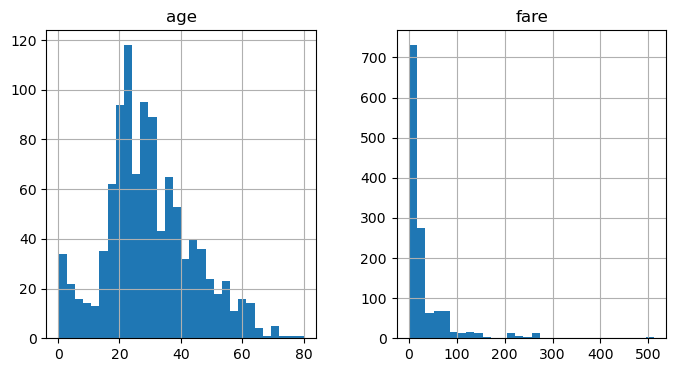

In [39]:
# let's explore the distribution of age

data[['age', 'fare']].hist(bins=30, figsize=(8,4))
plt.show()

## Equal width discretisation with pandas

In [40]:
# let's make labels to label the different bins

labels = ['bin_' + str(i) for i in range(1, 9)]

labels

['bin_1', 'bin_2', 'bin_3', 'bin_4', 'bin_5', 'bin_6', 'bin_7', 'bin_8']

In [41]:
# create binned age / discretise age

# create one column with labels
X_train['Age_disc_labels'], bins = pd.cut(
    x=X_train['age'], bins=8, labels=labels, retbins=True, precision=0, include_lowest=True)

# and one with bin boundaries
X_train['Age_disc'] = pd.cut(
    x=X_train['age'], bins=8, precision=0, include_lowest=True)

X_train.head(10)

,age,fare,Age_disc_labels,Age_disc
501,13.0,19.5000,bin_2,"(9.0, 19.0]"
588,4.0,23.0000,bin_1,"(-0.9, 9.0]"
402,30.0,13.8583,bin_4,"(28.0, 37.0]"
1193,40.5,7.7250,bin_5,"(37.0, 46.0]"
686,22.0,7.7250,bin_3,"(19.0, 28.0]"
971,39.0,7.8792,bin_5,"(37.0, 46.0]"
117,30.0,56.9292,bin_4,"(28.0, 37.0]"
540,2.0,26.0000,bin_1,"(-0.9, 9.0]"
294,49.0,110.8833,bin_6,"(46.0, 56.0]"
261,35.0,26.2875,bin_4,"(28.0, 37.0]"


In [42]:
# the limits of the intervals

bins

array([ 0.0928667,  9.3958625, 18.625025 , 27.8541875, 37.08335  ,
       46.3125125, 55.541675 , 64.7708375, 74.       ])

We can see in the above output how by discretising using equal width, we placed each Age observation within one interval / bin. For example, age=13 was placed in the 9-19 interval, whereas age 30 was placed into the 28-37 interval.

When performing equal width discretisation, we guarantee that the intervals are all of the same length, however there won't necessarily be the same number of observations in each of the intervals. See below:

In [43]:
# number of observations per interval

X_train.groupby('Age_disc', observed=False)['age'].count()

Age_disc
(-0.9, 9.0]      64
(9.0, 19.0]      90
(19.0, 28.0]    277
(28.0, 37.0]    243
(37.0, 46.0]    114
(46.0, 56.0]     77
(56.0, 65.0]     40
(65.0, 74.0]     11
Name: age, dtype: int64

Text(0, 0.5, 'Number of observations per bin')

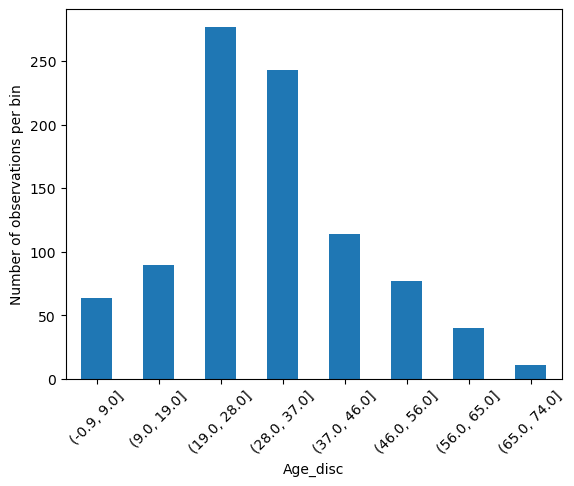

In [44]:
X_train.groupby('Age_disc', observed=False)['age'].count().plot.bar()
plt.xticks(rotation=45)
plt.ylabel('Number of observations per bin')

The majority of people on the Titanic were between 18-36 years of age.

Now, we can discretise Age in the test set, using the **same interval boundaries** that we calculated for the train set:

In [45]:
# discretize the test set
# note that we use the bin limits learned from the train set

X_test['Age_disc_labels'] = pd.cut(
    x=X_test['age'], bins=bins, labels=labels, precision=0, include_lowest=True)

X_test['Age_disc'] = pd.cut(x=X_test['age'], bins=bins, precision=0, include_lowest=True)

X_test.head()

,age,fare,Age_disc_labels,Age_disc
1139,38.0,7.8958,bin_5,"(37.0, 46.0]"
533,21.0,21.0000,bin_3,"(19.0, 28.0]"
459,42.0,27.0000,bin_5,"(37.0, 46.0]"
1150,3.0,14.5000,bin_1,"(-0.9, 9.0]"
393,25.0,31.5000,bin_3,"(19.0, 28.0]"


Text(0, 0.5, 'Number of observations per bin')

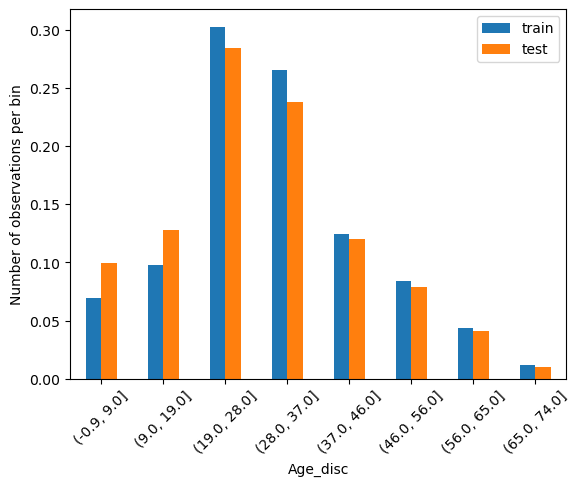

In [46]:
# if the distributions in train and test set are similar, we should expect similar propotion of
# observations in the different intervals in the train and test set
# let's see that below

t1 = X_train['Age_disc'].value_counts(normalize=True).sort_index()
t2 = X_test['Age_disc'].value_counts(normalize=True).sort_index()

tmp = pd.concat([t1, t2], axis=1)
tmp.columns = ['train', 'test']
tmp.plot.bar()
plt.xticks(rotation=45)
plt.ylabel('Number of observations per bin')

## Equal frequency discretization

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [83]:
# load the numerical variables of the Titanic Dataset

import pandas as pd
data = pd.read_csv('titanic.csv', usecols=['age', 'fare', 'survived'])
data.head()


,survived,age,fare
0,1,29.0000,211.3375
1,1,0.9167,151.5500
2,0,2.0000,151.5500
3,0,30.0000,151.5500
4,0,25.0000,151.5500


In [84]:
# Let's separate into train and test set

X_train, X_test, y_train, y_test = train_test_split(
    data[['age', 'fare']],
    data['survived'],
    test_size=0.3,
    random_state=0)

X_train.shape, X_test.shape

((916, 2), (393, 2))

The variables Age and Fare contain missing data, that I will fill by extracting a random sample of the variable.

In [85]:
def impute_na(data, variable):
    # function to fill NA with a random sample

    df = data.copy()

    # random sampling
    df[variable+'_random'] = df[variable]

    # extract the random sample to fill the na
    random_sample = X_train[variable].dropna().sample(
        df[variable].isnull().sum(), random_state=0)

    # pandas needs to have the same index in order to merge datasets
    random_sample.index = df[df[variable].isnull()].index
    df.loc[df[variable].isnull(), variable+'_random'] = random_sample

    return df[variable+'_random']

In [86]:
# replace NA in both train and test sets using the defined impute_na function
X_train['age'] = impute_na(X_train, 'age')
X_test['age'] = impute_na(X_test, 'age')

X_train['fare'] = impute_na(X_train, 'fare')
X_test['fare'] = impute_na(X_test, 'fare')

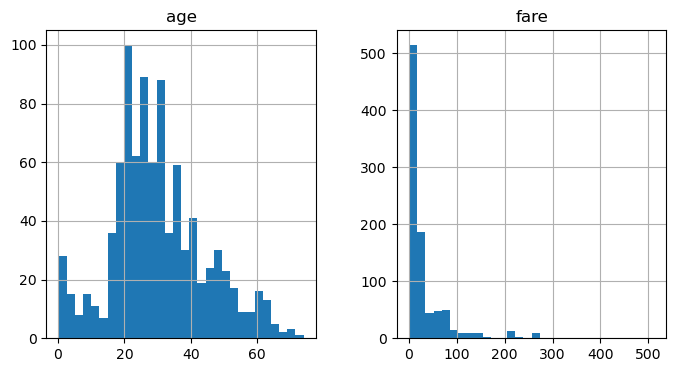

In [87]:
# let's explore the distribution of age

X_train[['age', 'fare']].hist(bins=30, figsize=(8,4))
plt.show()

In [88]:
# let's use pandas qcut (quantile cut) and I indicate that
# we want 10 bins.

# retbins = True indicates that I want to capture the limits
# of each interval (so I can then use them to cut the test set)

Age_disccretised, intervals = pd.qcut(
    X_train['age'], 10, labels=None, retbins=True, precision=3, duplicates='raise')

pd.concat([Age_disccretised, X_train['age']], axis=1).head(10)

,age,age
501,"(0.166, 16.0]",13.0
588,"(0.166, 16.0]",4.0
402,"(28.0, 31.0]",30.0
1193,"(36.0, 42.0]",40.5
686,"(20.0, 22.0]",22.0
971,"(36.0, 42.0]",39.0
117,"(28.0, 31.0]",30.0
540,"(0.166, 16.0]",2.0
294,"(42.0, 50.0]",49.0
261,"(31.0, 36.0]",35.0


We can see in the above output how by discretising using quantiles, we placed each Age observation within one interval. For example, age 30 was placed in the 28-31 interval, whereas age 49 was placed into the 42-50 interval.

Note how the interval widths are different.

We can visualise the interval cut points below:

In [89]:
intervals

array([ 0.1667, 16.    , 20.    , 22.    , 25.    , 28.    , 31.    ,
       36.    , 42.    , 50.    , 74.    ])

And because we generated the bins using the quantile cut method, we should have roughly the same amount of observations per bin. See below.

In [90]:
# roughly the same number of passengers per interval

Age_disccretised.value_counts()

age
(0.166, 16.0]    106
(31.0, 36.0]     106
(16.0, 20.0]      92
(22.0, 25.0]      92
(25.0, 28.0]      92
(28.0, 31.0]      90
(42.0, 50.0]      90
(36.0, 42.0]      85
(20.0, 22.0]      82
(50.0, 74.0]      81
Name: count, dtype: int64

In [91]:
# we can also add labels instead of having the interval boundaries, to the bins, as follows:

labels = ['Q'+str(i) for i in range(1,11)]
labels

['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10']

In [92]:
Age_disccretised, intervals = pd.qcut(X_train['age'], 10, labels=labels,
                                      retbins=True,
                                      precision=3, duplicates='raise')

Age_disccretised.head()

501     Q1
588     Q1
402     Q6
1193    Q8
686     Q3
Name: age, dtype: category
Categories (10, object): ['Q1' < 'Q2' < 'Q3' < 'Q4' ... 'Q7' < 'Q8' < 'Q9' < 'Q10']

In [93]:
# to apply the intervals to the test set, we need to extend
# the limits of the outer bins to -inf and +inf, so that if
# in the test set, there are smaller or bigger values than the
# minimum or maximum values in the train set, they can be
# accomodated in the outer intervals.
# Otherwise, they will be replaced by NaN.

# Prepend/Append infinities to accommodate outliers
intervals[0] = float("-inf")
intervals[len(intervals) - 1] = float("inf")

intervals

array([-inf,  16.,  20.,  22.,  25.,  28.,  31.,  36.,  42.,  50.,  inf])

In [94]:
# to transform the test set:
# we use pandas cut method (instead of qcut) and
# pass the quantile edges calculated in the training set

X_test['Age_disc_label'] = pd.cut(x = X_test['age'], bins=intervals, labels=labels)
X_test['Age_disc'] = pd.cut(x = X_test['age'], bins=intervals)

X_test.head(10)

,age,fare,Age_disc_label,Age_disc
1139,38.0,7.8958,Q8,"(36.0, 42.0]"
533,21.0,21.0000,Q3,"(20.0, 22.0]"
459,42.0,27.0000,Q8,"(36.0, 42.0]"
1150,3.0,14.5000,Q1,"(-inf, 16.0]"
393,25.0,31.5000,Q4,"(22.0, 25.0]"
1189,4.0,16.7000,Q1,"(-inf, 16.0]"
5,48.0,26.5500,Q9,"(42.0, 50.0]"
231,52.0,30.5000,Q10,"(50.0, inf]"
330,57.0,13.0000,Q10,"(50.0, inf]"
887,31.0,8.1125,Q6,"(28.0, 31.0]"


In [95]:
X_test['Age_disc_label'].isnull().sum()

0

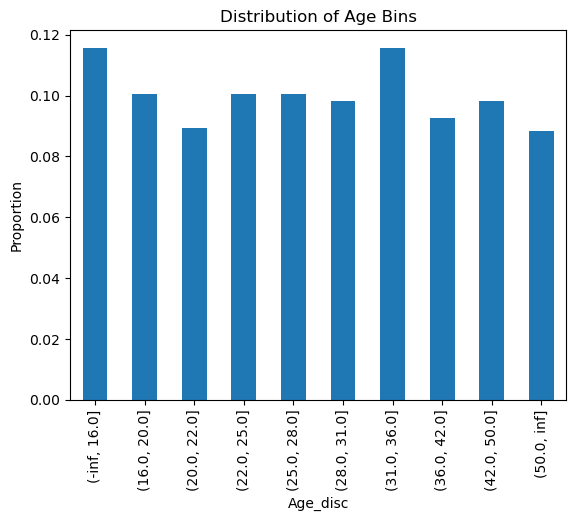

In [96]:
# Discretize 'age' into fixed intervals (bins) first
X_train['Age_disc'] = pd.cut(X_train['age'], bins=[-float('inf'), 16, 20, 22, 25, 28, 31, 36, 42, 50, float('inf')])

# Plot the proportion of observations per bin
X_train['Age_disc'].value_counts(normalize=True).sort_index().plot(kind='bar')

# Optional: Add labels
import matplotlib.pyplot as plt
plt.xlabel('Age_disc')
plt.ylabel('Proportion')
plt.title('Distribution of Age Bins')
plt.show()


If some intervals have less observations, which can happen with skewed distributions, to make the value spread more homogeneous, we could try using less intervals.

## Domain knowledge discretization

[Feature Engineering for Machine Learning Course](https://www.trainindata.com/p/feature-engineering-for-machine-learning)

Frequently, when engineering variables in a business setting, the business experts determine the intervals in which they think the variable should be divided so that it makes sense for the business. Typical examples include the discretization of variables like age and income.


Income, for example, is usually capped at a certain maximum value, and all incomes above that value fall into the last bucket. As per age, it is usually divided into certain groups according to the business need; for example, divisions into 0-21 (for under-aged), 20-30 (for young adults), 30-40, 40-60, and > 60 (for retired or close to) are frequent.

In [121]:
import pandas as pd
import matplotlib.pyplot as plt

In [122]:
# load the Titanic Dataset

data = pd.read_csv('titanic.csv', usecols=['age', 'survived'])

data.head()

,survived,age
0,1,29.0000
1,1,0.9167
2,0,2.0000
3,0,30.0000
4,0,25.0000


The variable Age contains missing data, that I will fill by extracting a random sample of the variable.

In [123]:
def impute_na(data, variable):
    df = data.copy()

    # random sampling
    df[variable+'_random'] = df[variable]

    # extract the random sample to fill the na
    random_sample = data[variable].dropna().sample(
        df[variable].isnull().sum(), random_state=0)

    # pandas needs to have the same index in order to merge datasets
    random_sample.index = df[df[variable].isnull()].index
    df.loc[df[variable].isnull(), variable+'_random'] = random_sample

    return df[variable+'_random']

In [124]:
# let's fill the missing data
data['age'] = impute_na(data, 'age')

In [128]:

# bucket labels
labels = ['0-20', '20-40']
# bucket boundaries
bins = [-0.001, 20, 40]

# discretisation
data['Age_buckets_labels'] = pd.cut(data['age'], bins=bins, labels=labels)
data['Age_buckets'] = pd.cut(data['age'], bins=bins)
data.head()


,survived,age,Age_buckets,Age_buckets_labels
0,1,29.0000,"(20.0, 40.0]",20-40
1,1,0.9167,"(-0.001, 20.0]",0-20
2,0,2.0000,"(-0.001, 20.0]",0-20
3,0,30.0000,"(20.0, 40.0]",20-40
4,0,25.0000,"(20.0, 40.0]",20-40


In [129]:
data.tail()

,survived,age,Age_buckets,Age_buckets_labels
1304,0,14.5,"(-0.001, 20.0]",0-20
1305,0,39.0,"(20.0, 40.0]",20-40
1306,0,26.5,"(20.0, 40.0]",20-40
1307,0,27.0,"(20.0, 40.0]",20-40
1308,0,29.0,"(20.0, 40.0]",20-40


Above we can observe the buckets into which each Age observation was placed. For example, age 14 was placed into the 0-20 bucket.

Let's explore the number of observations and survival rate per bucket after this arbitrary discretisation method.

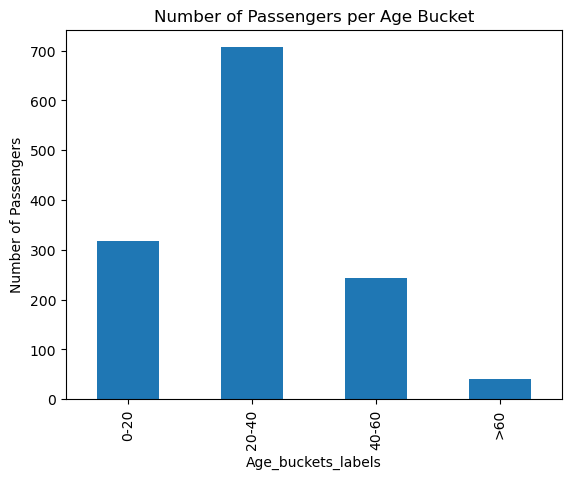

In [133]:
# Define bucket boundaries and labels
bins = [-0.001, 20, 40, 60, float('inf')]
labels = ['0-20', '20-40', '40-60', '>60']

# Apply discretization
data['Age_buckets_labels'] = pd.cut(data['age'], bins=bins, labels=labels)

# Plot number of passengers per age bucket
data['Age_buckets_labels'].value_counts().sort_index().plot(kind='bar')

# Beautify plot
import matplotlib.pyplot as plt
plt.xlabel('Age_buckets_labels')
plt.ylabel('Number of Passengers')
plt.title('Number of Passengers per Age Bucket')
plt.xticks(rotation=90)
plt.show()


C:\Users\karun\AppData\Local\Temp\ipykernel_12780\2276088921.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('Age_buckets_labels')['survived'].mean().plot(kind='bar')


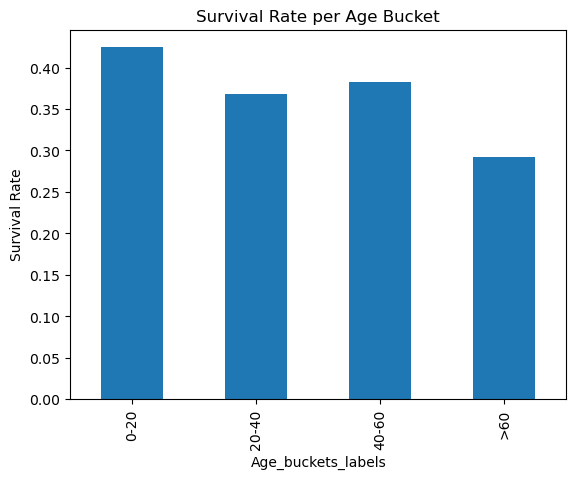

In [134]:
# Calculate survival rate per age bucket
data.groupby('Age_buckets_labels')['survived'].mean().plot(kind='bar')

# Beautify the plot
import matplotlib.pyplot as plt
plt.xlabel('Age_buckets_labels')
plt.ylabel('Survival Rate')
plt.title('Survival Rate per Age Bucket')
plt.xticks(rotation=90)
plt.show()


## Peer to peer

Let's explore discretisation using domain knowledge in a different business scenario. I will use the loan book from the peer to peer lending company. This dataset contains information on loans given to people, and the financial characteristics of those people as well as the loan performance.

In [138]:
# I will load only the income declared by the borrower for the demonstration

data = pd.read_csv('loan.csv', usecols=['income'])

data.head()

,income
0,84600.0
1,102000.0
2,69840.0
3,100386.0
4,95040.0


In [139]:
data['income'].describe()

count    1.000000e+04
mean     7.157229e+04
std      5.286105e+04
min      0.000000e+00
25%      4.365000e+04
50%      6.045000e+04
75%      8.536000e+04
max      2.185000e+06
Name: income, dtype: float64

<Axes: >

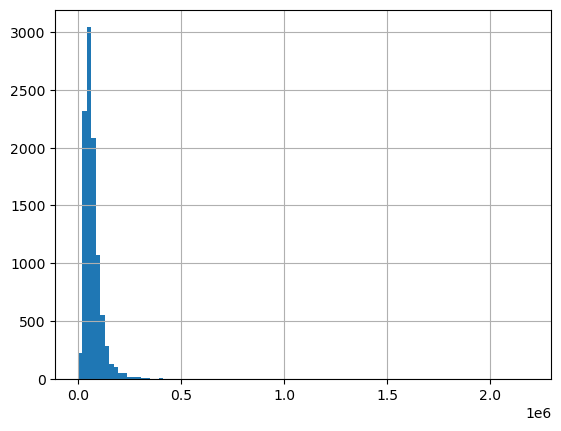

In [140]:
# let's inspect the distribution of Incomes

data['income'].hist(bins=100)

<Axes: >

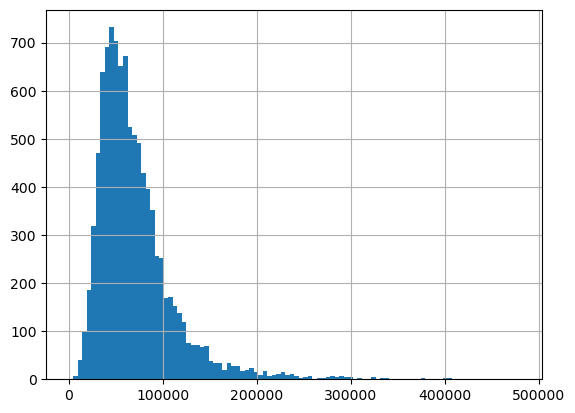

In [141]:
# and now let's look at the lower incomes in more detail

data[data['income']<500000]['income'].hist(bins=100)

We can see that the majority of the population earns below 150,000. So we may want to make a cap there.

In [143]:
# bucket interval
income_bins = [65000, 90000, 150000]

# bucket labels
income_labels = ['65-90k', '90-150k']

# discretisation
data['Income_buckets'] = pd.cut(data['income'], bins=income_bins, labels=income_labels)
data.head()


,income,Income_buckets
0,84600.0,65-90k
1,102000.0,90-150k
2,69840.0,65-90k
3,100386.0,90-150k
4,95040.0,90-150k


In [144]:
data.tail()

,income,Income_buckets
9995,98000.0,90-150k
9996,36270.0,NaN
9997,52250.0,NaN
9998,80040.0,65-90k
9999,72000.0,65-90k


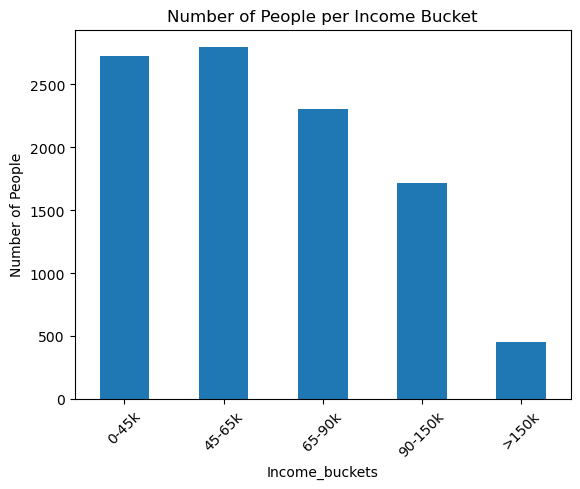

In [145]:
# Define income bucket boundaries
income_bins = [0, 45000, 65000, 90000, 150000, float('inf')]

# Define bucket labels
income_labels = ['0-45k', '45-65k', '65-90k', '90-150k', '>150k']

# Discretization
data['Income_buckets'] = pd.cut(data['income'], bins=income_bins, labels=income_labels)

# Plot number of people per income bucket
data['Income_buckets'].value_counts().sort_index().plot(kind='bar')

# Beautify the plot
import matplotlib.pyplot as plt
plt.xlabel('Income_buckets')
plt.ylabel('Number of People')
plt.title('Number of People per Income Bucket')
plt.xticks(rotation=45)
plt.show()


## Discretization with k-means clustering

In [146]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer

In [148]:
# load the numerical variables of the Titanic Dataset

data = pd.read_csv('titanic.csv', usecols=['age', 'fare', 'survived'])
data.head()

,survived,age,fare
0,1,29.0000,211.3375
1,1,0.9167,151.5500
2,0,2.0000,151.5500
3,0,30.0000,151.5500
4,0,25.0000,151.5500


In [149]:
# Let's separate into train and test set

X_train, X_test, y_train, y_test = train_test_split(
    data[['age', 'fare']],
    data['survived'],
    test_size=0.3,
    random_state=0)

X_train.shape, X_test.shape

((916, 2), (393, 2))

The variables Age and Fare contain missing data, that I will fill by extracting a random sample of the variable.

In [150]:
def impute_na(data, variable):
    # function to fill NA with a random sample

    df = data.copy()

    # random sampling
    df[variable+'_random'] = df[variable]

    # extract the random sample to fill the na
    random_sample = X_train[variable].dropna().sample(
        df[variable].isnull().sum(), random_state=0)

    # pandas needs to have the same index in order to merge datasets
    random_sample.index = df[df[variable].isnull()].index
    df.loc[df[variable].isnull(), variable+'_random'] = random_sample

    return df[variable+'_random']

In [158]:
# Replace NA values in 'age'
X_train['age'] = X_train['age'].fillna(X_train['age'].median())
X_test['age'] = X_test['age'].fillna(X_train['age'].median())

# Replace NA values in 'fare'
X_train['fare'] = X_train['fare'].fillna(X_train['fare'].median())
X_test['fare'] = X_test['fare'].fillna(X_train['fare'].median())


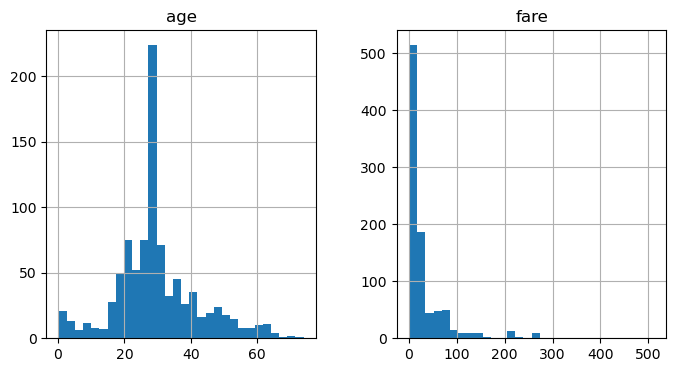

In [159]:
# Let's explore the distribution of age and fare
X_train[['age', 'fare']].hist(bins=30, figsize=(8, 4))
plt.show()


In [160]:
disc = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='kmeans', subsample=None)

disc.set_output(transform="pandas")

disc.fit(X_train[['age', 'fare']])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


KBinsDiscretizer(encode='ordinal', n_bins=4, strategy='kmeans', subsample=None)

In [161]:
disc.bin_edges_

array([array([ 0.1667    , 19.69185833, 34.33831588, 50.06387208, 74.        ]),
       array([  0.        ,  48.38317511, 155.62486898, 371.03119259,
              512.3292    ])                                         ],
      dtype=object)

In [169]:
from sklearn.preprocessing import KBinsDiscretizer

# Create the discretizer
kbd = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')

# Fit on training data
train_t = pd.DataFrame(
    kbd.fit_transform(X_train[['age', 'fare']]),
    columns=['age', 'fare'],
    index=X_train.index
)

# Transform test data
test_t = pd.DataFrame(
    kbd.transform(X_test[['age', 'fare']]),
    columns=['age', 'fare'],
    index=X_test.index
)

# Convert float to int if desired
train_t = train_t.astype(int)
test_t = test_t.astype(int)

# Display result
train_t.head()


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


,age,fare
501,0,0
588,0,0
402,1,0
1193,1,0
686,0,0


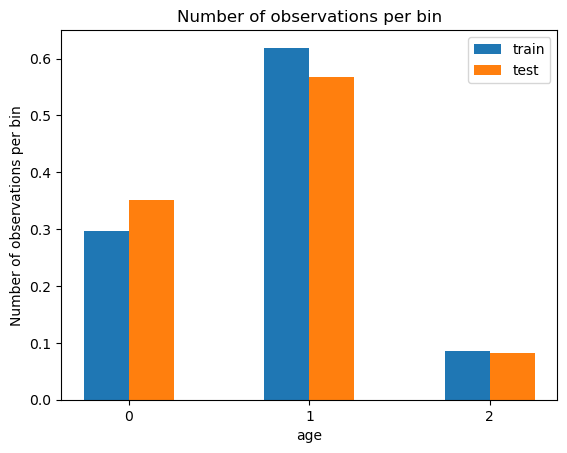

In [174]:
import matplotlib.pyplot as plt
import numpy as np

# Get value counts for each bin in age column
train_counts = train_t['age'].value_counts(normalize=True).sort_index()
test_counts = test_t['age'].value_counts(normalize=True).sort_index()

# Set up bar positions
bins = np.arange(len(train_counts))
width = 0.25  # width of the bars

# Create the plot
plt.bar(bins - width/2, train_counts, width=width, label='train')
plt.bar(bins + width/2, test_counts, width=width, label='test')

# Axis labeling
plt.xlabel('age')
plt.ylabel('Number of observations per bin')
plt.title('Number of observations per bin')
plt.xticks(bins)  # Set bin labels as x-axis ticks
plt.legend()
plt.show()


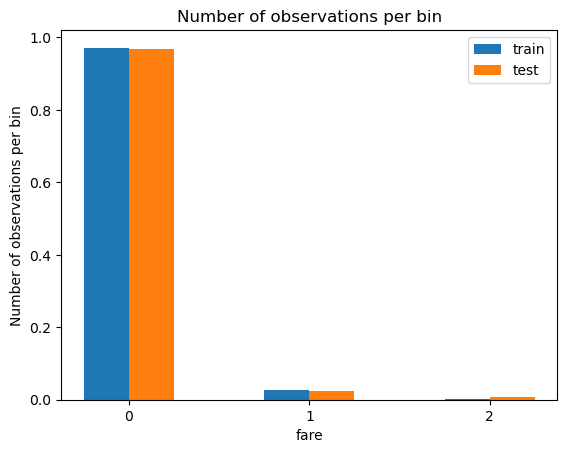

In [180]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate normalized bin frequencies for 'fare'
train_counts = train_t['fare'].value_counts(normalize=True).sort_index()
test_counts = test_t['fare'].value_counts(normalize=True).sort_index()

# Define bin positions
bins = np.arange(len(train_counts))
width = 0.25

# Create grouped bar chart
plt.bar(bins - width/2, train_counts, width=width, label='train')
plt.bar(bins + width/2, test_counts, width=width, label='test')

# Axis labeling
plt.xlabel('fare')
plt.ylabel('Number of observations per bin')
plt.title('Number of observations per bin')
plt.xticks(bins)  # Set bin labels as x-axis ticks
plt.legend()
plt.show()


## Discretization with Decision Trees


In [192]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

In [193]:
# load the numerical variables of the Titanic Dataset

data = pd.read_csv('titanic.csv', usecols=['age', 'survived','fare'])


data.head()

,survived,age,fare
0,1,29.0000,211.3375
1,1,0.9167,151.5500
2,0,2.0000,151.5500
3,0,30.0000,151.5500
4,0,25.0000,151.5500


In [194]:
# Let's separate into train and test set

X_train, X_test, y_train, y_test = train_test_split(
    data[['age', 'fare']],
    data['survived'],
    test_size=0.3,
    random_state=0)

X_train.shape, X_test.shape

((916, 2), (393, 2))

The variables Age and Fare contain missing data, that I will fill by extracting a random sample of the variable.

In [195]:
def impute_na(data, variable):
    df = data.copy()

    # random sampling
    df[variable+'_random'] = df[variable]
    # extract the random sample to fill the na
    random_sample = X_train[variable].dropna().sample(df[variable].isnull().sum(), random_state=0)
    # pandas needs to have the same index in order to merge datasets
    random_sample.index = df[df[variable].isnull()].index
    df.loc[df[variable].isnull(), variable+'_random'] = random_sample

    return df[variable+'_random']

In [196]:
# Replace NA in 'age'
X_train['age'] = X_train['age'].fillna(X_train['age'].median())
X_test['age'] = X_test['age'].fillna(X_train['age'].median())

# Replace NA in 'fare'
X_train['fare'] = X_train['fare'].fillna(X_train['fare'].median())
X_test['fare'] = X_test['fare'].fillna(X_train['fare'].median())


In [197]:
# example: build Classification tree using Age to predict Survived

tree_model = DecisionTreeClassifier(max_depth=2)

tree_model.fit(X_train['age'].to_frame(), y_train)

DecisionTreeClassifier(max_depth=2)

In [213]:
# Step 1: Define age bins for classification
# You can customize the bins as needed
age_bin = pd.cut(X_train['age'], bins=[0, 10, 30, 50, 80], labels=False)

# Step 2: Train the decision tree model
tree_model.fit(X_train[['fare']], age_bin)

# Step 3: Replace values with predictions
X_train['age_prob'] = np.round(tree_model.predict_proba(X_train[['fare']])[:, 1], 3)
X_test['age_prob'] = np.round(tree_model.predict_proba(X_test[['fare']])[:, 1], 3)

# Step 4: Show result
X_train.head(10)


,age,fare,age_prob
501,13.0,19.5000,0.583
588,4.0,23.0000,0.583
402,30.0,13.8583,0.583
1193,28.0,7.7250,0.788
686,22.0,7.7250,0.788
971,28.0,7.8792,0.788
117,30.0,56.9292,0.412
540,2.0,26.0000,0.412
294,49.0,110.8833,0.412
261,35.0,26.2875,0.412


In [214]:
# let's explore how many end points the tree created

X_train['age_prob'].unique()

array([0.583, 0.788, 0.412, 0.522])

Text(0, 0.5, 'Survived')

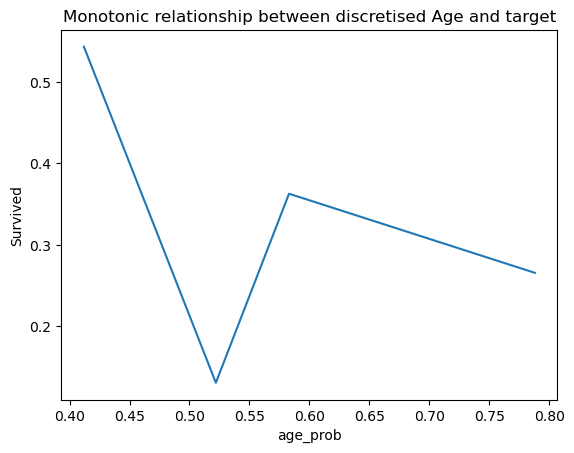

In [215]:
# relationship with target

y_train.groupby(X_train['age_prob']).mean().plot()
plt.title('Monotonic relationship between discretised Age and target')
plt.ylabel('Survived')

Text(0, 0.5, 'Survived')

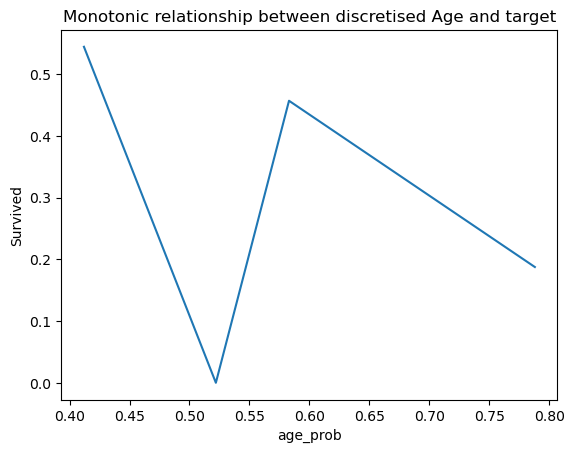

In [216]:
y_test.groupby(X_test['age_prob']).mean().plot()
plt.title('Monotonic relationship between discretised Age and target')
plt.ylabel('Survived')

<Axes: xlabel='age_prob'>

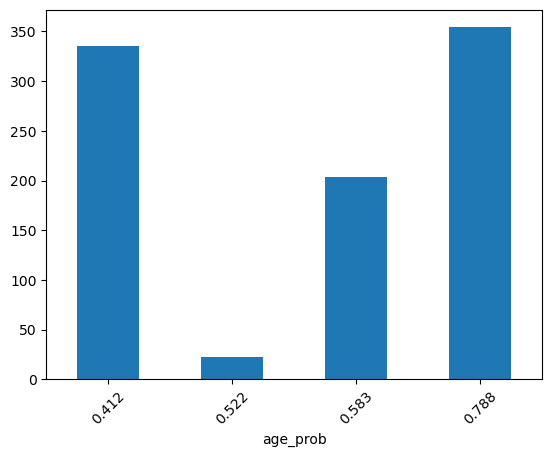

In [217]:
# number of passengers per node / bin

X_train['age_prob'].value_counts().sort_index().plot.bar(rot=45)

<Axes: xlabel='age_prob'>

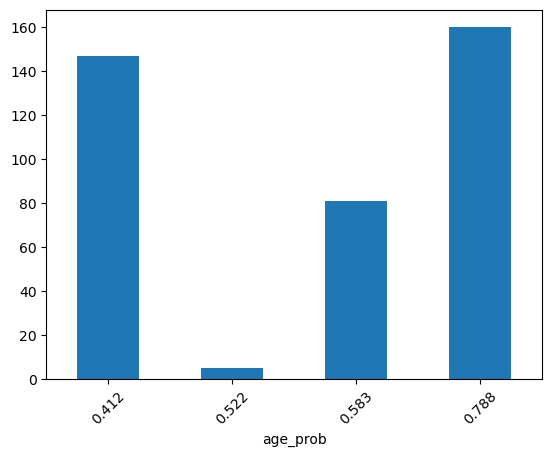

In [218]:
X_test['age_prob'].value_counts().sort_index().plot.bar(rot=45)

In [219]:
# let's see the Age limits buckets generated by the tree
# by capturing the minimum and maximum age per each probability bucket,
# we get an idea of the bucket cut-offs

tmp = pd.concat( [X_train.groupby(['age_prob'])['age'].min(),
            X_train.groupby(['age_prob'])['age'].max()], axis=1)

tmp.columns = ["min", "max"]

tmp

,min,max
age_prob,,
0.412,1.0000,71.0
0.522,9.0000,61.0
0.583,0.1667,61.0
0.788,0.8333,74.0


In [220]:
# get inteval edges

bins = list(X_train.groupby(['age_prob'])['age'].min().sort_values().values)

bins

[0.1667, 0.8333, 1.0, 9.0]

In [221]:
# expand to plus and minus inf

bins[0] = -np.inf
bins.append(np.inf)

bins

[-inf, 0.8333, 1.0, 9.0, inf]

## Tree visualization

In [230]:
!pip install graphviz

Defaulting to user installation because normal site-packages is not writeable


In [231]:
import graphviz
from sklearn.tree import export_graphviz

In [232]:
dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=["age"],
    filled=True, rounded=True,
    special_characters=True)

graph = graphviz.Source(dot_data)

graph

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

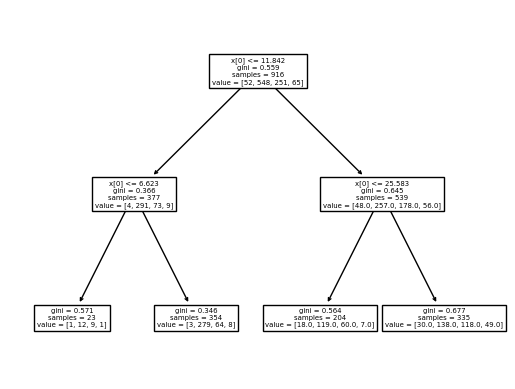

In [242]:
# alternative way of visualizing

from sklearn.tree import plot_tree

plot_tree(tree_model)
plt.show()

## Optimizing the decision tree

There are a number of parameters that we could optimize to obtain the best split using decision trees.

I will optimize the tree depth for this demonstration. But remember that we could also optimize the remaining parameters of the decision tree.

Visit [sklearn website](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier) to see which other parameters can be optimized.

In [234]:
from sklearn.model_selection import GridSearchCV

In [235]:
parameters = {'max_depth':[1, 2, 3, 4]}

clf = GridSearchCV(
    tree_model,
    parameters,
    cv=3,
    refit=True, # so that it returns a fitted model
)

clf.fit(X_train["age"].to_frame(), y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(max_depth=2),
             param_grid={'max_depth': [1, 2, 3, 4]})

In [236]:
# the results

pd.DataFrame(clf.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004020,0.000849,0.002978,0.000783,1,{'max_depth': 1},0.620915,0.603279,0.583607,0.602600,0.015239,3
1,0.004000,0.000817,0.003333,0.000472,2,{'max_depth': 2},0.611111,0.603279,0.600000,0.604797,0.004661,2
2,0.004941,0.000826,0.003004,0.000805,3,{'max_depth': 3},0.611111,0.600000,0.616393,0.609168,0.006832,1
3,0.004000,0.000815,0.002825,0.001917,4,{'max_depth': 4},0.604575,0.590164,0.606557,0.600432,0.007306,4


In [237]:
# the most interesting part of the resutls

pd.DataFrame(clf.cv_results_)[['params', 'mean_test_score', 'std_test_score']]

,params,mean_test_score,std_test_score
0,{'max_depth': 1},0.602600,0.015239
1,{'max_depth': 2},0.604797,0.004661
2,{'max_depth': 3},0.609168,0.006832
3,{'max_depth': 4},0.600432,0.007306


In [238]:
# the best depth

clf.best_params_

{'max_depth': 3}

In [239]:
# the trained decision tree

clf.best_estimator_

DecisionTreeClassifier(max_depth=3)

In [241]:
# "discretize" the variable

X_train['age_prob'] = np.round(
    clf.best_estimator_.predict_proba(X_train['age'].to_frame())[:, 1], 3)


X_test['age_prob'] = np.round(
    clf.best_estimator_.predict_proba(X_test['age'].to_frame())[:,1],3)

Text(0.5, 1.0, 'Monotonic relationship between discretised Age and target')

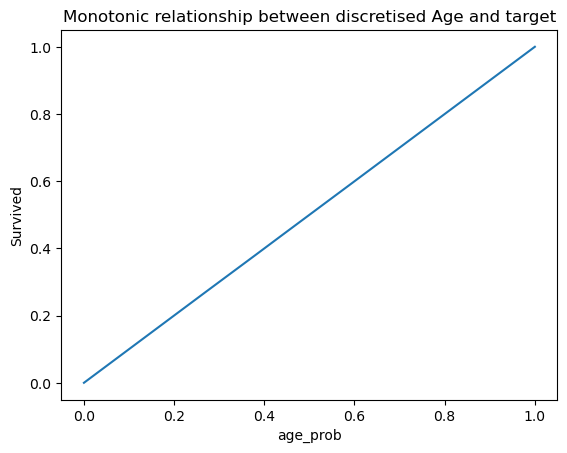

In [243]:
df_plot = pd.concat([X_train['age_prob'], y_train.rename("Survived")], axis=1)
df_plot.groupby('age_prob')['Survived'].mean().plot()
plt.ylabel('Survived')
plt.title('Monotonic relationship between discretised Age and target')

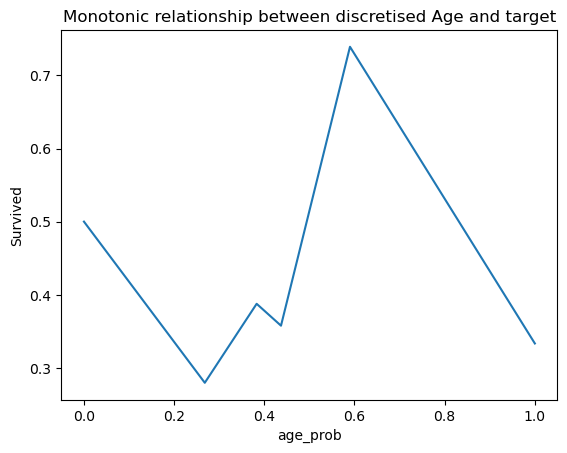

In [246]:
import matplotlib.pyplot as plt

# Add 'Survived' to X_test if not already there
X_test['Survived'] = y_test  # y_test should be defined earlier

# Group by age_prob and compute the mean survival
grouped = X_test.groupby('age_prob')['Survived'].mean()

# Plot the line chart
plt.plot(grouped.index, grouped.values)

# Set labels and title
plt.xlabel('age_prob')
plt.ylabel('Survived')
plt.title('Monotonic relationship between discretised Age and target')
plt.show()


Now the monotonic relationship is not totally maintained in the test. Probably because there are few samples in the upper buckets:

<Axes: xlabel='age_prob'>

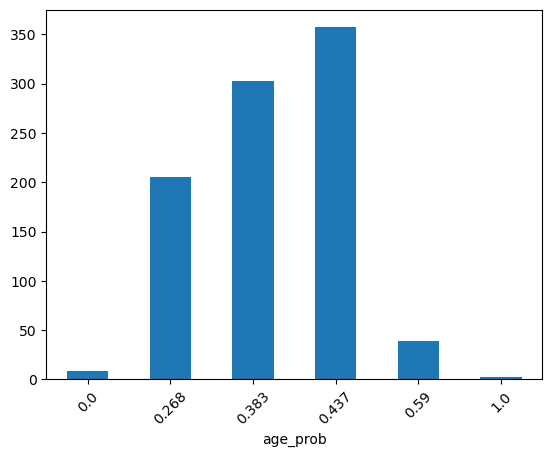

In [247]:
# number of passengers per probabilistic bucket / bin

X_train['age_prob'].value_counts().sort_index().plot.bar(rot=45)

<Axes: xlabel='age_prob'>

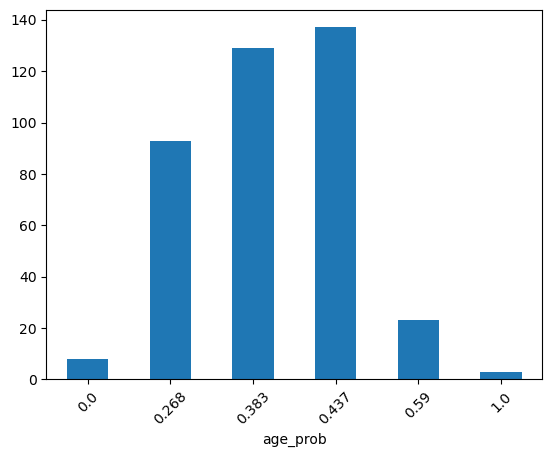

In [248]:
# number of passengers per probabilistic bucket / bin

X_test['age_prob'].value_counts().sort_index().plot.bar(rot=45)

We could try and optimise the decision tree further to see if we can keep the monotonic relationship. Or alternatively, directly test the model performance with these engineered features and see if they add any value.

In [249]:
# get the interval limists

bins = list(X_train.groupby(['age_prob'])['age'].min().sort_values().values)

bins[0] = -np.inf
bins.append(np.inf)

bins

[-inf, 7.0, 8.0, 9.0, 28.0, 29.0, inf]

## Binarization

[Feature Engineering for Machine Learning Course](https://www.trainindata.com/p/feature-engineering-for-machine-learning)

We will use a new dataset that contains words. Check the folder 02-Datasets and the notebook `donwload-prepare-store-enron-data.ipynb` to get hold of the data.

In [250]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Binarizer

In [262]:
data = pd.read_csv('content/bag_of_words.csv')
data.head()


FileNotFoundError: [Errno 2] No such file or directory: 'content/bag_of_words.csv'

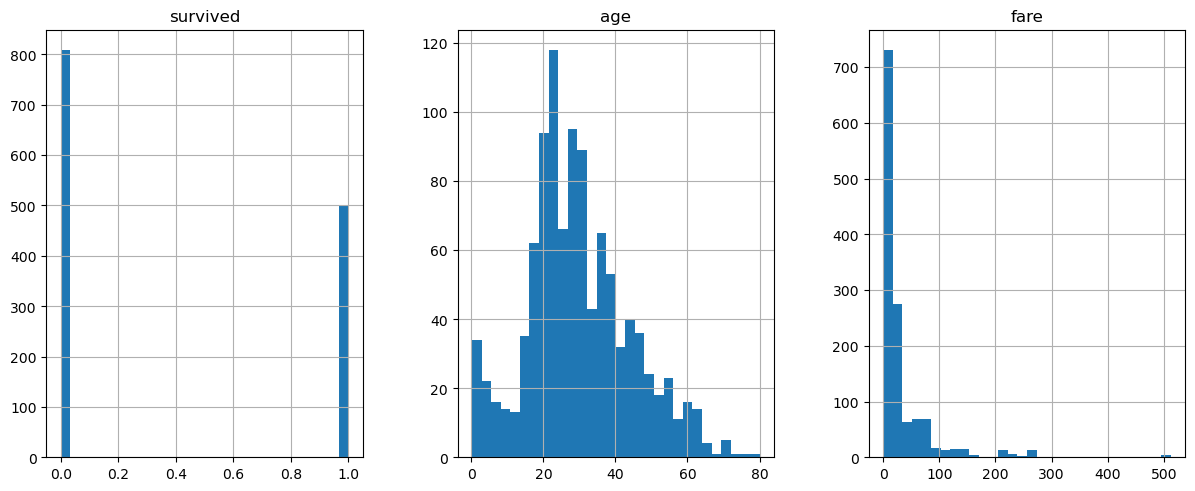

In [263]:
# Plot histograms to inspect variable distributions

data.hist(bins=30, figsize=(20, 20), layout=(3, 4))
plt.show()

In [264]:
data.nunique()

survived      2
age          98
fare        281
dtype: int64

In [265]:
data.describe()

,survived,age,fare
count,1309.000000,1046.000000,1308.000000
mean,0.381971,29.881135,33.295479
std,0.486055,14.413500,51.758668
min,0.000000,0.166700,0.000000
25%,0.000000,21.000000,7.895800
50%,0.000000,28.000000,14.454200
75%,1.000000,39.000000,31.275000
max,1.000000,80.000000,512.329200


In [266]:
# set up a Binarizer:

binarizer = Binarizer(threshold=0).set_output(transform="pandas")

In [267]:
# fit to data

data_t = binarizer.fit_transform(data)

ValueError: Input X contains NaN.
Binarizer does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [268]:
data_t.describe()

NameError: name 'data_t' is not defined

In [269]:
data_t.hist(figsize=(20, 20), layout=(3, 4))
plt.show()

NameError: name 'data_t' is not defined

In [270]:
# Let's plot binarized variables:

variables = data_t.columns.to_list()

plt.figure(figsize=(20, 20), constrained_layout=True)

for i in range(10):

    # location in figure
    ax = plt.subplot(3, 4, i + 1)

    # variable to plot
    var = variables[i]

    # determine proportion of observations per bin
    t = data_t[var].value_counts(normalize=True)
    t.plot.bar(ax=ax)

    plt.xticks(rotation=0)
    plt.ylabel("Observations per bin")

    # add variable name as title
    ax.set_title(var)

plt.show()

NameError: name 'data_t' is not defined